# VQC Hardware Inference
Load pre-trained weights, run on Qiskit SamplerV2.
**To go to real hardware: swap cell 2 only.**

## 1 — Imports

In [9]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.circuit.library import StatePreparation
from qiskit.primitives import StatevectorSampler

print('Imports OK')

Imports OK


In [11]:
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2, Session
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

service = QiskitRuntimeService(token='INSERT TOKEN', instance='INSERT CRN')
backend = service.least_busy(operational=True, simulator=False, min_num_qubits=6)
print(f'Using backend: {backend.name}')
sampler = SamplerV2(backend)
sampler.options.max_execution_time = 300

REAL_HW = True
SHOTS   = 1024   # shots per circuit

# Pass manager for transpilation — run once, reuse for all circuits
pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
print(f'Pass manager ready (optimization_level=3)')

qiskit_runtime_service._discover_account:WARNING:2026-04-15 10:35:13,463: Loading account with the given token. A saved account will not be used.


Using backend: ibm_fez
Pass manager ready (optimization_level=3)


## 2 — Data

In [12]:
LABELS   = [1, 3, 5, 7]
LABEL_MAP = {1: 0, 3: 1, 5: 2, 7: 3}

digits = load_digits()
mask   = np.isin(digits.target, LABELS)
X_raw  = digits.data[mask].astype(np.float64)
y_raw  = np.array([LABEL_MAP[l] for l in digits.target[mask]])

# Unit-norm normalise — eq. (2)
X_raw /= np.linalg.norm(X_raw, axis=1, keepdims=True) + 1e-10

_, X_te, _, y_te = train_test_split(
    X_raw, y_raw, test_size=0.32, random_state=42, stratify=y_raw
)
print(f'Test samples: {len(X_te)}')

Test samples: 233


In [13]:
print(X_te.shape)      # (N, 64)
print(np.linalg.norm(X_te[0]))  # must be ~1.0

(233, 64)
0.9999999999985054


## 3 — Load trained weights

In [14]:
N_QUBITS  = 6
N_LAYERS  = 7
N_LAYERS_ADA = 3   # must match what was used during training
N_WEIGHTS = N_QUBITS * N_LAYERS * 3

weights = np.load('trained_weights.npy')
print(f'Weights loaded — shape: {weights.shape}')  # expect (126,)

Weights loaded — shape: (126,)


## 4 — Build + run circuits

In [15]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit.library import StatePreparation

N_QUBITS = 6
N_LAYERS = 7

# Bit-reversal to match Qiskit's state preparation convention
def bit_reverse_state(vec, n_qubits):
    out = np.zeros_like(vec)
    for i, amp in enumerate(vec):
        j = int(f"{i:0{n_qubits}b}"[::-1], 2)
        out[j] = amp
    return out

def build_circuit(x, weights, n_layers):
    qc = QuantumCircuit(N_QUBITS, 2)

    # Normalise input vector and apply bit reversal
    x = np.asarray(x, dtype=np.float64)
    x = x / (np.linalg.norm(x) + 1e-12)

    x = bit_reverse_state(x, N_QUBITS)

    # State preparation - amplitude encoding
    qc.append(StatePreparation(x.tolist()), range(N_QUBITS))

    # Ansatz — paper eq. (3-5): Rx-Rz-Rx per qubit + nearest-neighbour CNOTs
    p = 0
    for _ in range(n_layers):
        for q in range(N_QUBITS):
            qc.rx(float(weights[p]), q)
            qc.rz(float(weights[p+1]), q)
            qc.rx(float(weights[p+2]), q)
            p += 3
        for q in range(N_QUBITS - 1):
            qc.cx(q, q+1)

    qc.measure([5, 4], [0, 1])

    return qc

In [16]:
preds = []
BATCH = 50

# Build and TRANSPILE all circuits before submitting
print('Building and transpiling circuits...')
raw_circuits = [build_circuit(x, weights, N_LAYERS) for x in X_te]
circuits     = [pm.run(qc) for qc in raw_circuits]   # transpile to backend native gates
print(f'Transpiled {len(circuits)} circuits')
print(f'Example depth after transpile: {circuits[0].depth()}')
print(f'Example CX count: {circuits[0].count_ops().get("cx", 0)}')

for start in range(0, len(circuits), BATCH):
    batch   = circuits[start:start+BATCH]
    job = sampler.run(batch, shots=SHOTS)
    try:
        results = job.result()
    except KeyboardInterrupt:
        print("Interrupted! Cancelling job...")
        job.cancel()
        raise

    for i in range(len(batch)):
        counts = results[i].data.c.get_counts()
        probs  = np.zeros(4)
        total  = sum(counts.values())
        for bitstring, count in counts.items():
            bitstring = bitstring.replace(' ', '')
            idx = int(bitstring, 2)
            if idx < 4:
                probs[idx] += count / total
        preds.append(int(np.argmax(probs)))

    print(f'Batch {start//BATCH + 1}/{-(-len(circuits)//BATCH)} done')

from sklearn.metrics import accuracy_score
acc = accuracy_score(y_te, preds)
print(f'Single VQC accuracy: {acc*100:.1f}%')

Building and transpiling circuits...
Transpiled 233 circuits
Example depth after transpile: 512
Example CX count: 0
Batch 1/5 done
Batch 2/5 done
Batch 3/5 done
Batch 4/5 done
Batch 5/5 done
Single VQC accuracy: 78.5%


In [17]:
weights_list = [
    np.load('trained_ada_weights_0.npy'),
    np.load('trained_ada_weights_1.npy'),
    np.load('trained_ada_weights_2.npy'),
]
alphas = np.load('ada_alphas.npy')
print(f'Loaded {len(weights_list)} weak models, alphas: {np.round(alphas, 3)}')

# Pre-transpile all AdaBoost circuits (3 models × N_test circuits)
print('Transpiling AdaBoost circuits...')
all_transpiled = []
for m, w in enumerate(weights_list):
    raw = [build_circuit(x, w, N_LAYERS_ADA) for x in X_te]
    transpiled = [pm.run(qc) for qc in raw]
    all_transpiled.append(transpiled)
    print(f'  Model {m+1}/{len(weights_list)} transpiled')

preds = []
BATCH = 50

for start in range(0, len(X_te), BATCH):
    X_batch = X_te[start:start+BATCH]
    n       = len(X_batch)

    # Flatten: [model0_sample0, model0_sample1, ..., model1_sample0, ...]
    flat_circuits = [
        all_transpiled[m][start + i]
        for m in range(len(weights_list))
        for i in range(n)
    ]

    results = sampler.run(flat_circuits, shots=SHOTS).result()

    for i in range(n):
        final_probs = np.zeros(4)
        for m in range(len(weights_list)):
            counts = results[m * n + i].data.c.get_counts()
            probs  = np.zeros(4)
            total  = sum(counts.values())
            for bitstring, count in counts.items():
                bitstring = bitstring.replace(' ', '')
                idx = int(bitstring, 2)
                if idx < 4:
                    probs[idx] += count / total
            final_probs += alphas[m] * probs
        preds.append(int(np.argmax(final_probs)))

    print(f'Batch {start//BATCH + 1}/{-(-len(X_te)//BATCH)} done')

from sklearn.metrics import accuracy_score
ada_acc = accuracy_score(y_te, preds)
print(f'AdaBoost accuracy : {ada_acc*100:.1f}%')
print(f'Single VQC accuracy: {acc*100:.1f}%')
print(f'Improvement: {(ada_acc - acc)*100:+.1f}%')

Loaded 3 weak models, alphas: [3.553 2.011 2.324]
Transpiling AdaBoost circuits...
  Model 1/3 transpiled
  Model 2/3 transpiled
  Model 3/3 transpiled
Batch 1/5 done
Batch 2/5 done
Batch 3/5 done
Batch 4/5 done
Batch 5/5 done
AdaBoost accuracy : 83.7%
Single VQC accuracy: 78.5%
Improvement: +5.2%


## 6 — Confusion matrix

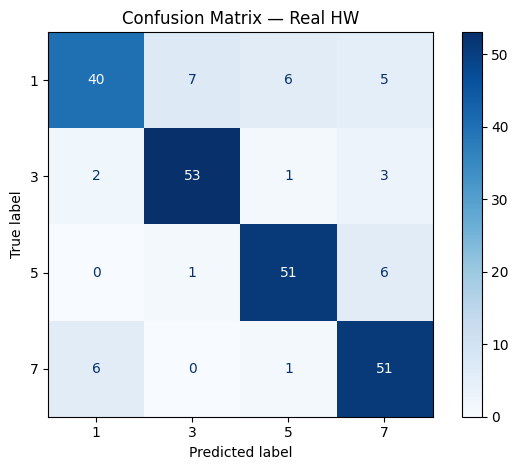

In [18]:
cm   = confusion_matrix(y_te, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS)
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix — {"Real HW" if REAL_HW else "Simulator"}')
plt.tight_layout()
plt.show()

In [20]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService(token='qZ-20bfgGciizhIlLl-tg7HWm0orY1qptbC60yEfyFqu', instance='crn:v1:bluemix:public:quantum-computing:us-east:a/fba540bb8b584818a1466aada8d10e0d:5c59a832-2adc-4871-be86-db068f61591b::')

jobs = service.jobs(limit=10)

for job in jobs:
    print(job.job_id(), job.status())

qiskit_runtime_service._discover_account:WARNING:2026-04-15 10:44:55,321: Loading account with the given token. A saved account will not be used.


d7fkv321u7fs739m4uig DONE
d7fkugt6agrc738iqsug DONE
d7fku1a1u7fs739m4tc0 DONE
d7fktim2cugc739qn8mg DONE
d7fkt3m2cugc739qn87g DONE
d7fksotd4lnc73ffg5v0 DONE
d7fksge2cugc739qn7jg DONE
d7fks7d6agrc738iqqkg DONE
d7fkrutd4lnc73ffg540 DONE
d7fkrld6agrc738iqpug DONE
